# Previsão de Falhas Estruturais Aplicadas no <span style="color:red;">Motor Brushless</span>

---

### Integrantes do grupo: 
- <span style="color:yellow;">Enrico Magalhães</span>;
-  Hugo Samuel;
- <span style="color:brown;">Vinícius Fernandes</span>;
- <span style="color:green;">Vitor Belo</span>.

---

### Parâmetros do grupo moto-propulsor utilizado: 
(Como contexto e limitação orçamentária desse estudo, destaca-se que nenhum componente foi adquirido para o projeto. Todos os materiais, e inclusive os ensaios, estavam disponíveis e foram realizados na oficina da equipe Trem Ki Voa Micro. O uso gratuito e facilitado desses componetes foi devido à todos os integrantes do grupo serem membros atuais ou ex-integrantes da equipe).

- *Motor:* Scorpion SII-4035-450;
- *Hélice:* Master Airscrew 16×10"× 3;
- *Baterias:* LiFePO4 e LIPO;
- *ESC:* ESCTurnigy® Plush-32 120A HV?????? SERÁ?;
- *Receptor:* FrSky® V8FR-II;
-*Regulador de tensão:* Castle Creations® CCBEC10A.

### Sensores:
- *Allegro® ACS712ELCTR*;
- *Célula de carga*;
- *Arduino UNO*;

---

### Repositório no Github: https://github.com/vitorvespoli/MachineLearning_Trabalho1

---

---


### Definição do problema

A SAE BRASIL é uma associação dedicada ao avanço da engenharia de mobilidade no país. Uma de suas principais iniciativas é o Projeto SAE BRASIL AeroDesign, um programa educacional que desafia estudantes universitários a conceber, projetar, construir e voar aeronaves rádio-controladas, simulando os mesmos desafios enfrentados pela indústria aeronáutica.

Na 26ª Competição SAE Brasil AeroDesign, uma falha no motor impediu o voo da equipe **Trem Ki Voa Micro** (equipe de competição da UFSJ) em uma de suas tentativas oficiais. O evento foi decisivo na pontuação final, resultando na obtenção do vice-campeonato nacional por uma margem de dois pontos em relação ao primeiro colocado.

A partir disso, surgiu a necessidade de desenvolver um modelo capaz de prever falhas com base nos dados de funcionamento do sistema, evitando que falhas passem despercebidas antes de um voo oficial. Dentre as inúmeras falhas que podem interferir no sistema, para a realização desse trabalho, foram escolhidas 3 falhas principais:

- Desbalanceamento de hélice;
- Hélice quebrada;
- Rotação invertida do motor.

<div align="center">
<img src="pics\teste.png" width="1000">
</div>

## Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statistics as st
from scipy.signal import savgol_filter

### <span style="color:brown;">Função para Gráficos Técnicos</span>

A seção abaixo apresenta a função `plot_technical()`, desenvolvida para a geração de gráficos de linhas de forma padronizada, flexível e reutilizável. O principal objetivo dessa função é facilitar a visualização de sinais experimentais e séries temporais, permitindo analisar o comportamento das variáveis medidas ao longo das amostras ou do tempo.

Diferentemente de uma plotagem simples, a função foi estruturada para atender diferentes cenários de análise, sendo capaz de representar tanto uma única curva quanto múltiplas curvas simultaneamente em um mesmo gráfico. Essa característica é especialmente útil para comparações entre condições distintas de operação, como funcionamento normal e modos de falha.

Inicialmente, a instrução `plt.figure(figsize=figsize)` define o tamanho da figura. Em seguida, a função realiza uma verificação automática do parâmetro `y`, identificando se os dados fornecidos correspondem a uma única série ou a uma coleção de séries. Caso seja detectada apenas uma curva, os dados são reorganizados internamente para manter compatibilidade com o restante da estrutura da função.

Após essa etapa, um laço `for` percorre todas as curvas disponíveis, utilizando a instrução `plt.plot()` para desenhar cada sinal com seus respectivos rótulos, espessura de linha e marcadores opcionais.

Na sequência, são adicionados título, nomes dos eixos, configuração de fontes e grade visual, proporcionando melhor legibilidade e aparência técnica ao gráfico. Quando múltiplas curvas estão presentes, a legenda é exibida automaticamente, facilitando a identificação de cada conjunto de dados.

Além disso, a função permite exportar a figura em alta resolução, possibilitando sua utilização em relatórios acadêmicos, apresentações e documentação técnica.

Os principais parâmetros disponíveis na função são:

- `x`: valores do eixo horizontal;  
- `y`: série única ou conjunto de séries a serem plotadas;  
- `title`: título do gráfico;  
- `xlabel`: legenda do eixo horizontal;  
- `ylabel`: legenda do eixo vertical;  
- `labels`: nomes das curvas exibidas na legenda;  
- `linewidth`: espessura das linhas;  
- `markers`: marcadores opcionais para os pontos;  
- `figsize`: dimensões da figura;  
- `grid`: ativação da grade visual;  
- `save`: opção para salvar a imagem;  
- `filename`: nome do arquivo exportado;  
- `dpi`: resolução da imagem.

No contexto deste trabalho, a função `plot_technical()` é utilizada para representar sinais experimentais relacionados às variáveis do sistema, como **tração, torque, corrente, potência e tensão**, permitindo analisar respostas transitórias, regime permanente, comparações entre ensaios e diferenças entre condições normais e modos de falha.

In [2]:
def plot_technical(
    x,
    y,
    title="Título do Gráfico",
    xlabel="Eixo X",
    ylabel="Eixo Y",
    labels=None,
    linewidth=2.0,
    markers=None,
    figsize=(8, 5),
    grid=True,
    save=False,
    filename="grafico.png",
    dpi=300
):
    plt.figure(figsize=figsize)

    # Detecta se y é curva única ou lista de curvas
    if isinstance(y, (pd.Series, np.ndarray, list, tuple)):
        if len(y) > 0 and not isinstance(y[0] if isinstance(y, (list, tuple, np.ndarray)) else y.iloc[0], (list, tuple, np.ndarray, pd.Series)):
            y = [y]
    else:
        y = [y]

    n_curves = len(y)

    if labels is None:
        labels = [f"Curva {i+1}" for i in range(n_curves)]

    if markers is None:
        markers = [None] * n_curves

    for i in range(n_curves):
        plt.plot(
            x,
            y[i],
            label=labels[i],
            linewidth=linewidth,
            marker=markers[i]
        )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.7)

    if labels is not None:
        plt.legend(fontsize=10)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

### <span style="color:brown;">Funções para Histogramas</span>

A seção abaixo apresenta funções desenvolvidas para automatizar a geração de histogramas, com o objetivo de auxiliar a análise exploratória dos dados experimentais obtidos no sistema moto-propulsor.

O histograma é uma ferramenta estatística utilizada para representar a distribuição de frequência de uma variável numérica, permitindo identificar padrões importantes, como concentração de valores, dispersão, assimetria e possíveis comportamentos anormais.

Com o intuito de tornar o processo de visualização mais organizado e reutilizável, foram implementadas duas abordagens complementares:

- `plot_histogram()`: responsável pela geração de histogramas individuais, utilizada quando se deseja analisar detalhadamente uma única variável;

- `subplot_histogram()`: desenvolvida para exibir múltiplos histogramas em uma única figura no formato de subplots, permitindo comparar simultaneamente diferentes variáveis medidas no sistema.

Ambas as funções foram construídas com parâmetros configuráveis, como número de divisões (`bins`), tamanho da figura (`figsize`), transparência (`alpha`), grade visual (`grid`) e opção de exportação da imagem (`save`), proporcionando flexibilidade para diferentes aplicações.

No contexto deste trabalho, essas funções são empregadas para investigar o comportamento estatístico de variáveis como **tração, torque, corrente, potência e tensão**, contribuindo para a identificação de padrões operacionais e diferenças entre condições normais e modos de falha.

In [3]:
def plot_histogram(
    data,
    bins=30,
    title="Histograma",
    xlabel="Valores",
    ylabel="Frequência",
    figsize=(7,5),
    density=False,
    alpha=0.75,
    grid=True,
    save=False,
    filename="histograma.png",
    dpi=300
):
   

    plt.figure(figsize=figsize)

    plt.hist(
        data,
        bins=bins,
        density=density,
        alpha=alpha,
        edgecolor='black'
    )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

In [4]:
def subplot_histogram(
    dataframe,
    header,
    bins=30,
    title="Histograma",
    xlabel="Valores",
    ylabel="Frequência",
    figsize=(12,8),
    density=False,
    alpha=0.75,
    grid=True,
    save=False,
    filename="histograma.png",
    dpi=300
):
   

    fig, axs = plt.subplots(2,3,figsize=figsize)
    axs = axs.flatten()
    for i, h in enumerate(header):
        axs[i].hist(
            dataframe[h],
            bins=bins,
            density=density,
            alpha=alpha,
            edgecolor='black'
        )
        axs[i].set_title(header[i])
        axs[i].set_xlabel("Valor")
        axs[i].set_ylabel("Frequência")
        axs[i].grid(grid, linestyle=':', alpha=alpha)

    fig.delaxes(axs[5])

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

### <span style="color:brown;">Função para Subplots de Boxplots</span>

A seção abaixo apresenta a função `subplot_boxplot()`, desenvolvida para automatizar a geração de múltiplos boxplots em uma única figura. O principal objetivo dessa função é facilitar a análise comparativa de diversas variáveis simultaneamente, permitindo visualizar medidas estatísticas resumidas de cada grandeza monitorada no sistema.

O boxplot, também conhecido como diagrama de caixa, é uma ferramenta gráfica amplamente utilizada para representar a distribuição de dados com base em estatísticas descritivas. Por meio dele, é possível observar de forma rápida:

- valor mínimo;  
- primeiro quartil (Q1);  
- mediana;  
- terceiro quartil (Q3);  
- valor máximo;  
- possíveis valores discrepantes (*outliers*);  
- dispersão dos dados.

A função recebe como entrada um `dataframe` contendo os dados experimentais e uma lista `header`, responsável por indicar quais colunas serão analisadas. Para cada variável informada, é gerado automaticamente um boxplot em uma grade de subplots no formato **2 linhas por 3 colunas**, totalizando até seis posições gráficas.

Internamente, a instrução `plt.subplots(2,3)` é utilizada para criar a estrutura da figura, enquanto o método `flatten()` reorganiza os eixos em um vetor unidimensional, simplificando o preenchimento sequencial de cada subplot.

Em seguida, um laço `for` percorre as colunas fornecidas em `header`, utilizando a função `boxplot()` para gerar individualmente os diagramas de caixa de cada variável. Antes da plotagem, valores ausentes são removidos com `dropna()`, garantindo maior robustez na visualização.

Cada gráfico recebe título, legenda do eixo vertical e grade visual, tornando a interpretação mais clara e organizada. Caso a quantidade de variáveis seja inferior ao número total de posições disponíveis na grade, os eixos excedentes são removidos automaticamente, melhorando a apresentação final da figura.

Além disso, a função possui parâmetros configuráveis, como:

- `title`: título geral da figura;  
- `ylabel`: legenda do eixo vertical;  
- `figsize`: dimensões da figura;  
- `grid`: ativação da grade visual;  
- `showmeans`: exibição da média;  
- `save`: opção para salvar a imagem gerada;  
- `filename`: nome do arquivo exportado;  
- `dpi`: resolução da imagem.

O uso dessa abordagem modular contribui para maior padronização visual, reaproveitamento de código e agilidade na análise exploratória dos dados.

No contexto deste trabalho, os subplots de boxplots são especialmente úteis para comparar simultaneamente variáveis como **tração, torque, corrente, potência e tensão**, permitindo identificar diferenças entre condições normais e modos de falha, além de evidenciar dispersões, deslocamentos de mediana e possíveis valores atípicos.

In [ ]:
def subplot_boxplot(
    dataframe,
    header,
    title="Boxplots",
    ylabel="Valores",
    figsize=(12,8),
    grid=True,
    showmeans=True,
    save=False,
    filename="boxplot.png",
    dpi=300
):

    fig, axs = plt.subplots(2, 3, figsize=figsize)
    axs = axs.flatten()

    for i, h in enumerate(header):

        axs[i].boxplot(
            dataframe[h].dropna(),
            patch_artist=True,
            showmeans=showmeans
        )

        axs[i].set_title(h)
        axs[i].set_ylabel(ylabel)
        axs[i].grid(grid, linestyle=':', alpha=0.7)

    # Remove eixos sobrando
    for j in range(len(header), len(axs)):
        fig.delaxes(axs[j])

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

### <span style="color:green;">Diretório dos dados coletados</span>

A seção abaixo foi criada para o armazenamento dos diretórios em que os dados coletados se encontram. Estes são armazenados em um dicionário, sendo possível acessar o diretório de cada operação a partir das chaves definidas ("normal", "desbalanceada", "quebrada", "invertida"). O uso deste dicionário se torna evidente algumas seções à frente.

A variável "thisFolder" é responsável por armazenar o diretório da pasta que o arquivo atual ".ipynb" se encontra. A variável "dataFolder" armazena o diretório da pasta com os dados coletados, a partir da junção dos caminhos provido pela função "os.path.join()". De modo semelhante, as pastas de cada operação são armazenadas nas variáveis "normalFolder", "desbalanceadaFolder", "quebradaFolder" e "invertidaFolder".

In [6]:
# Armazena o diretório de onde o arquivo .ipynb se encontra
thisFolder = os.getcwd()

# Armazena o diretório da pasta com as outras pastas de operações
dataFolder = os.path.join(thisFolder, "dados_coletados")

# Seleciona as pastas de cada operação, separadamente
desbalanceadaFolder = os.path.join(dataFolder, "helice_desbalanceada")
quebradaFolder = os.path.join(dataFolder, "helice_quebrada")
normalFolder = os.path.join(dataFolder, "normal")
invertidaFolder = os.path.join(dataFolder, "rotacao_invertida")

# Um dicionário é criado para acessar cada diretório com uma chave
folders = {
    "normal": normalFolder,
    "desbalanceada": desbalanceadaFolder,
    "quebrada": quebradaFolder,
    "invertida": invertidaFolder
    
}

In [7]:
def processar_filtro_sinais(folder, file):
    try:
        # Cria pasta
        file = os.path.join(folder, file)

        # Lê as colunas: Tempo(A=0), Tração(B=1), Torque(C=2), Tensão(E=4), Corrente(F=5), Potência(H=7)
        cols = [0, 1, 2, 4, 5, 7]
        if file.endswith('.csv'):
            try: df = pd.read_csv(file, usecols=cols, sep=None, engine='python')
            except: df = pd.read_csv(file, usecols=cols)
        else:
            df = pd.read_excel(file, usecols=cols)
            
        df.columns = ['Tempo', 'Tracao', 'Torque', 'Tensao', 'Corrente', 'Potencia']
        df = df.dropna()
        
        # Força tudo a ser float para evitar problema do int64 e float64
        df = df.astype(float)
        
        # Deixa positivo os valores
        for col in df.columns: 
            df[col] = df[col].abs()
            
        df.reset_index(drop=True, inplace=True) 

        # Sincroniza o tempo
        limite = df['Tracao'].median() * 0.05
        idx = df[df['Tracao'] > limite].index
        if len(idx) == 0: return None
        
        df = df.loc[idx[0]:].reset_index(drop=True)
        df['Tempo'] = df['Tempo'] - df['Tempo'].iloc[0] 

        # DataFrame para armazenar os dados limpos e os vetores de localização dos dados
        df_limpo = df[['Tempo']].copy()

        # Define as variáveis
        variaveis = [
            ('Tracao', 'Tração (gf)'),
            ('Torque', 'Torque (N.m)'), 
            ('Tensao', 'Tensão (V)'),
            ('Corrente', 'Corrente (A)'),
            ('Potencia', 'Potência (W)')
        ]

        total_filtrados = 0 

        # Processa cada
        for var, eixo_y in variaveis:
            sinal = df[var]

            # Tendência móvel
            tend_movel = sinal.rolling(window=51, center=True).median().bfill().ffill()

            # Detecta falhas
            falhas = np.abs(sinal - tend_movel) > (sinal.median() * 0.15)
            total_filtrados += falhas.sum()

            # Interpolação linear
            corrigido = sinal.copy()
            corrigido.loc[falhas] = np.nan
            corrigido = corrigido.interpolate(method='linear').bfill().ffill()

            # Suaviza
            sinal_final = savgol_filter(corrigido, window_length=11, polyorder=3)

            # Substituição segura usando np.where
            f_exp = pd.Series(falhas) | pd.Series(falhas).shift(1).fillna(False) | pd.Series(falhas).shift(-1).fillna(False)
            sinal_exportacao = np.where(f_exp, sinal_final, sinal)
            
            #SALVA O DADO E O VETOR "CORRIGIDO"
            df_limpo[var] = sinal_exportacao
            df_limpo[f'Corrigido_{var}'] = f_exp.astype(int) # Transforma True/False em 1/0

            # Plota gráfico
            plt.figure(figsize=(14, 6))
            plt.plot(df['Tempo'], sinal, label='Real', color='orange', alpha=0.6, linewidth=2)

            # Máscara visual
            remendos = pd.Series(sinal_final)
            remendos[~f_exp] = np.nan 

            plt.plot(df['Tempo'], remendos, label='Filtro', color='blue', linewidth=3)
            
            plt.title(f'{var}: {file}', fontsize=14, fontweight='bold')
            plt.xlabel('Tempo (s)', fontsize=12)
            plt.ylabel(eixo_y, fontsize=12)
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            
            # Salva imagem
            
            plt.show()
            plt.close()
            

        # Exibe contagem
        print(f"\nQuantidade de dados filtrados: {total_filtrados}")
        
        #RETORNA A VARIÁVEL pro jupyter
        return df_limpo
            
    except Exception as e:
        print(f"\n[ERRO]: {e}")
        return None

#Solicita arquivo
tratamentoFolder = os.path.join(dataFolder, "dados_para_tratamento")
dados_prontos_quebrada = processar_filtro_sinais(tratamentoFolder, "helice_quebrada_4.xlsx")
dados_prontos_invertida = processar_filtro_sinais(tratamentoFolder, "rotacao_invertida_3.xlsx")


[ERRO]: [Errno 2] No such file or directory: 'c:\\Users\\vinicius.silvestre\\OneDrive - RADIX ENGENHARIA E DESENVOLVIMENTO DE SOFTWARE S A\\Área de Trabalho\\Faculdade\\machine learning\\MachineLearning_Trabalho1\\dados_coletados\\dados_para_tratamento\\helice_quebrada_4.xlsx'

[ERRO]: [Errno 2] No such file or directory: 'c:\\Users\\vinicius.silvestre\\OneDrive - RADIX ENGENHARIA E DESENVOLVIMENTO DE SOFTWARE S A\\Área de Trabalho\\Faculdade\\machine learning\\MachineLearning_Trabalho1\\dados_coletados\\dados_para_tratamento\\rotacao_invertida_3.xlsx'


## <span style="color:green;">Análise Exploratória de Dados</span>
Após a coleta e tratamento dos dados, esses foram segmentados em duas seções de transitórios (transitório inicial e final) e uma seção de regime estacionário, em que o manche do motor permanece no limite máximo, corroborando na tendência de máximo consumo de potência disponível conforme as capacidades do sistema.

A função abaixo realiza a identificação dessas seções. Primeiramente, há a aquisição da média referente aos valores entre 30% e 70% dos dados (seção aproximada de regime permanente), após isso, o algoritmo realiza uma varredura nas linhas dos dados de corrente em Ampères, sendo um dos principais parâmetros que governa o comportamento do sistema, como na potência fornecida e na rotação do motor. A varredura ocorre visando encontrar os pontos de chaveamento de seções. O chaveamento entre o transitório inicial e o regime permanente é quando há o encontro de um dado entre 99 e 130% da média obtida, somando-se 10 posições à esse ponto. Já o chaveamento entre o regime permanente e o transitório final ocorre quando há o encontro de um valor entre 30% e 82% do valor da média obtida, subtraindo 8 posições desse ponto. A busca pelo ponto de chaveamento entre o regime permanente e transitório final ocorre somente se o primeiro ponto de chaveamento já estiver obtido.

Os valores utilizados foram definidos a partir de testes realizados com as bases de dados adquiridas. A adição/subtração de pontos mantém a segmentação mais conservativa, evitando manter picos ou vales provindos do comportamento dos transitórios nas seções de regime permanente. 

Ao final do código há um exemplo demonstrando a operação da função de segmentação de seções por meio dos valores normalizados pela média de corrente e tração adquiridos, mostrando que, apesar do uso da corrente como parâmetro de verificação, a relação se estabelece para outras variáveis. O valor de tensão foi omitido, visto que, por ser a medição da tensão da bateria, ela não apresenta seções de transitório bem definidas como os outros parâmetros medidos.

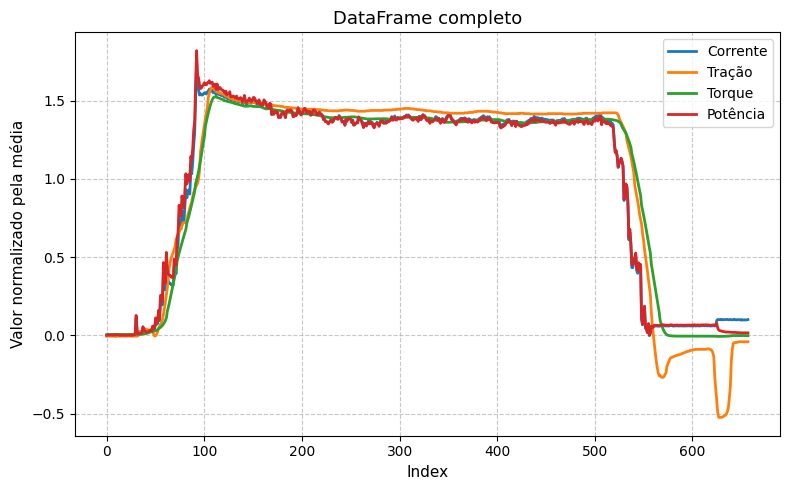

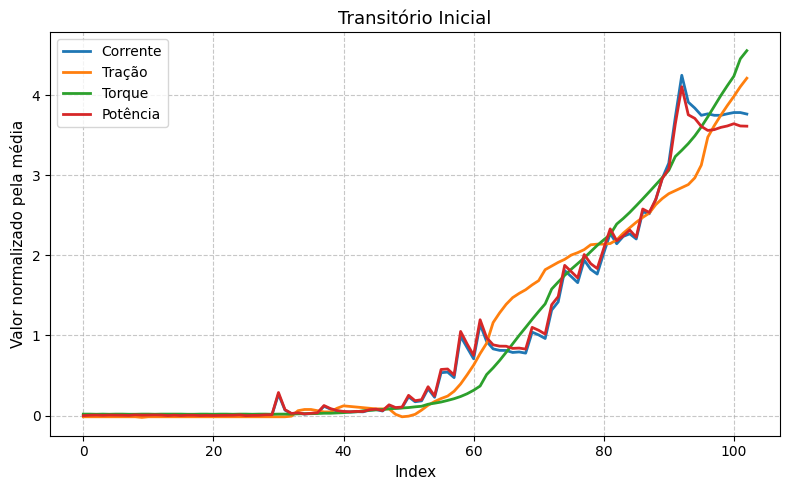

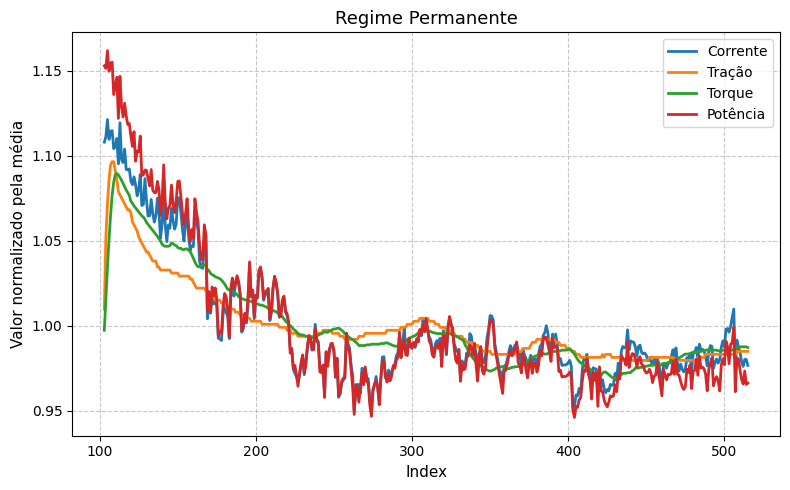

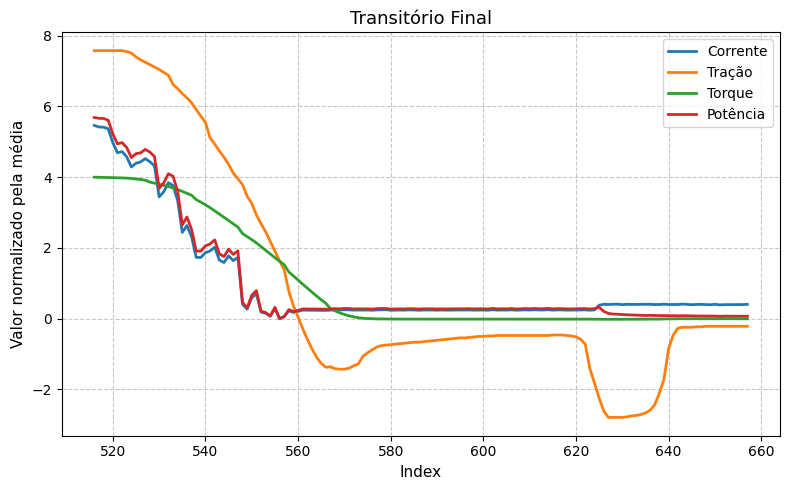

In [8]:
def transitory_stacionary(df):
    
    # Adquire a localização em índice da coluna de "Corrente_A" do dataframe utilizado como argumento
    # Há a soma "+ 1" pois, para a indexação em cada linha através do da função "itertuples()" do pandas
    loc_i = df.columns.get_loc("Corrente_A") + 1

    # Obtém os intervalos em que estão localizados 30% e 70% dos valores de corrente armazenados
    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)

    # Cria um novo dataframe cujos valores são aqueles entre q1 e q3, ou seja, 40% dos dados centrais
    df_40 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    # "Flag" criada para indicar que o ponto que termina o transitório inicial e inicia a seção do regime permanente já foi identificado
    flag_stac = False

    # "Flag" para indicar que o ponto que termina o regime permanente e inicia o transitório final ainda não foi identificado
    flag_transitory_1 = True

    # Valor em que o transitório 2 será armazenado
    transitory_2 = None

    # Média do dataframe com os 40% dos dados centrais
    mean = df_40["Corrente_A"].mean()
    
    # Para cada linha (row) no dataframe, numerando as iterações pela variável "idx"...
    for idx, row in enumerate(df.itertuples()):

        # Verifica se o valor de corrente está entre 99% e 130% da média, além de verificar se flag_transitory_1 == True
        if ((np.abs(row[loc_i]) >= 0.99*mean) & (np.abs(row[loc_i]) <= 1.3*mean) & flag_transitory_1):
            
            # O valor de índice atual somado a 10 posições é armazenado na variável "transitory_1"
            transitory_1 = idx + 12

            # As flags são atualizadas
            flag_stac = True
            flag_transitory_1 = False

        # Se a flag_stac == True... 
        if flag_stac:

            # Realiza a verificação se o valor atual de corrente está entre 30 e 82% da média
            if ((np.abs(row[loc_i]) <= 0.82*mean) & (np.abs(row[loc_i]) >= 0.3*mean)):
                
                # Armazena o índice atual subtraído de 8 posições na variável transitory_2
                transitory_2 = idx - 8
                break

    # O dataframe referente ao transitório inicial é definido
    df_0 = df.iloc[:transitory_1]

    # Se for for identificado o transitório final...
    if transitory_2 != None:

        # O dataframe do regime permanente é definido entre as duas posições armazenadas anteriormente
        df_1 = df.iloc[transitory_1:transitory_2]

        # O dataframe do transitório final é definido
        df_2 = df.iloc[transitory_2:]
    
    # Caso contrário...
    else:
        
        # O dataframe do regime permanente é definido entre a posição do "transitory_1" até o final do dataframe
        df_1 = df.iloc[transitory_1:]
        # O dataframe do transitório final é definido como "None" por não ter sido identificado
        df_2 = None

    return df_0, df_1, df_2

df_ex = pd.read_excel(os.path.join(quebradaFolder, "helicequebrada_6.xlsx"))
df0, df1, df2 = transitory_stacionary(df_ex)

plot_technical(df_ex.index, 
    [df_ex["Corrente_A"]/df_ex["Corrente_A"].mean(), 
     df_ex["Celula1_Kgf"]/df_ex["Celula1_Kgf"].mean(), 
     df_ex["Celula2_Kgf"]/df_ex["Celula2_Kgf"].mean(), 
     df_ex["Potencia_W"]/df_ex["Potencia_W"].mean()], 
    title="DataFrame completo", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração", "Torque", "Potência"])

plot_technical(df0.index, 
    [df0["Corrente_A"]/df0["Corrente_A"].mean(), 
     df0["Celula1_Kgf"]/df0["Celula1_Kgf"].mean(), 
     df0["Celula2_Kgf"]/df0["Celula2_Kgf"].mean(), 
     df0["Potencia_W"]/df0["Potencia_W"].mean()], 
    title="Transitório Inicial", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração", "Torque", "Potência"])

plot_technical(df1.index, 
    [df1["Corrente_A"]/df1["Corrente_A"].mean(), 
     df1["Celula1_Kgf"]/df1["Celula1_Kgf"].mean(), 
     df1["Celula2_Kgf"]/df1["Celula2_Kgf"].mean(), 
     df1["Potencia_W"]/df1["Potencia_W"].mean()], 
    title="Regime Permanente", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração", "Torque", "Potência"])

plot_technical(df2.index, 
    [df2["Corrente_A"]/df2["Corrente_A"].mean(), 
     df2["Celula1_Kgf"]/df2["Celula1_Kgf"].mean(), 
     df2["Celula2_Kgf"]/df2["Celula2_Kgf"].mean(), 
     df2["Potencia_W"]/df2["Potencia_W"].mean()], 
    title="Transitório Final", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração", "Torque", "Potência"])

Os parâmetros considerados relevantes para a análise do sistema foram organizados por meio da <span style="color:green;">classe statisticsParams</span>, definida na célula abaixo. O objetivo é que cada objeto seja um tipo de operação, armazenando informações da média, mediana, moda, valor máximo, valor mínimo, desvio padrão, assimetria e excesso de curtose para cada coluna presente no DataFrame da operação respectiva. Além desses valores, é possível armazenar também a quantidade de dados presentes para os transitórios e regime permanente.

In [9]:
class statisticsParams:
    def __init__(self, name = None, df = None, tr1_qty = None, regime_qty = None, tr2_qty = None):
        
        # Inicialização dos dicionários vazios
        mean = {}
        median = {}
        max = {}
        min = {}
        desv_padr = {}
        skew = {}
        kurtosis = {}
        mode = {}

        # Caso haja um argumento de df não nulo:
        if df is not None:

            # Adquire a lista com o cabeçalho do dataframe
            header = df.columns.to_list()    

            # Para cada elemento na lista do cabecalho...
            for h in header:
                mean[h] = df[h].mean()  # Adquire o valor da média para o parâmetro atual
                median[h] = df[h].median()  # Adquire o valor da mediana para o parâmetro atual
                max[h] = df[h].max()    # Adquire o valor máximo para o parâmetro atual
                min[h] = df[h].min()    # Adquire o valor mínimo para o parâmetro atual
                desv_padr[h] = st.stdev(df[h])  # Adquire o desvio padrão para o parâmetro atual
                skew[h] = df[h].skew()  # Adquire a assimetria entre os dados para o parâmetro atual
                kurtosis[h] = df[h].kurtosis()  # Adquire o excesso de curtose para o parâmetro atual
                mode[h] = st.mode(df[h])    # Adquire a moda para o parâmetro atual

            # Armazenamento do que foi medido nos parâmetros do objeto
            self.name = name
            self.header = header
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis
            self.mode = mode

            # Armazenamento nos parâmetros do objeto da quantidade de dados para cada regime de operação, sendo esses argumentos da classe.
            self.tr1_qty = tr1_qty
            self.regime_qty = regime_qty
            self.tr2_qty = tr2_qty

        # Caso o argumento "df" seja "None", os parâmetros da função se mantém como definidos no início, strings vazias ou zeros
        else:
            self.name = ""
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis
            self.mode = mode

            self.tr1_qty = 0
            self.regime_qty = 0
            self.tr2_qty = 0

Com o objetivo de visualizar as informações relevantes, a <span style="color:green;">função "stats_dataFrame"</span> abaixo foi definida, cujo argumento é um objeto da classe statisticParams, definida anteriormente. A função irá imprimir no terminal os valores armazenados no objeto para cada parâmetro (coluna) do DataFrame inicial.

Nota-se que, antes de realizar a impressão, há a organização dos valores em um DataFrame, cujas colunas são definidas pelas chaves (Parametro, Media, Mediana...) e as linhas são definidas pela iteração do cabeçalho obtido pelo objeto dado como entrada na função, obtendo os valores referentes à cada coluna.

Ao final, há a impressão da quantidade de dados para cada transitório e regime permanente, também.

In [10]:
def stats_dataFrame(class_param):
    
    resumo = pd.DataFrame({
            "Parametro": (h for h in class_param.header),
            "Media": (class_param.mean[h] for h in class_param.header),
            "Mediana": (class_param.median[h] for h in class_param.header),
            "Moda": (class_param.mode[h] for h in class_param.header),
            "Maximo": (class_param.max[h] for h in class_param.header),
            "Minimo": (class_param.min[h] for h in class_param.header),
            "Desvio padrao": (class_param.desv_padr[h] for h in class_param.header),
            "Assimetria": (class_param.skew[h] for h in class_param.header),
            "Excesso de curtose": (class_param.kurtosis[h] for h in class_param.header)
        })
    
    print("Transitorio 1, quantidade de dados = ", class_param.tr1_qty)
    print("Regime, quantidade de dados = ", class_param.regime_qty)
    print("Transitorio 2, quantidade de dados = ", class_param.tr2_qty)
    print(resumo)

A <span style="color:green;">função "concatDataframes"</span> abaixo foi feita com o objetivo de realizar o concatenamento de uma lista de DataFrames, que é o argumento da função. Em situações de múltiplas aquisições de dados referentes a uma única operação, pode ser útil e importante para a análise do comportamento do sistema obter um DataFrame resultante.

É importante ressaltar que, quando houver a necessidade de concatenar dados adquiridos, somente dados em regime permanente serão concatenados e analisados, a princípio, como é evidenciado nos passos posteriores deste notebook.

In [11]:
def concatDataframes(df_list):
    for i, df in enumerate(df_list):
        if i != 0:
            df_tot = pd.concat([df_tot, df], ignore_index=True)
        else:
            df_tot = df
    
    return df_tot

## <span style="color:green;">Estatística Descritiva e Análise Interpretativa </span>

O <span style="color:green;">algoritmo abaixo foi desenvolvido </span>com o objetivo de acessar os diretórios das operações e apresentar os dados relevantes a partir de funções definidas anteriormente. Os dados dispostos ao executar o algoritmo são referentes ao intervalo em regime permanente, com exceção da quantidade de dados, que há a inclusão para os transitórios e para o regime permanente. 



================== normal ==================

Transitorio 1, quantidade de dados =  377
Regime, quantidade de dados =  1243
Transitorio 2, quantidade de dados =  274
     Parametro        Media   Mediana      Moda     Maximo     Minimo  \
0  Celula1_Kgf  -672.056315  -641.000  -623.000  -588.0000  -858.0000   
1  Celula2_Kgf  2581.093323  2719.000  2863.000  3047.0000  1896.0000   
2     Tensao_V    13.445020    13.550    13.760    14.2500    12.5300   
3   Corrente_A    31.321601    30.150    28.890    38.1600    24.4600   
4   Potencia_W   421.947599   407.048   513.248   523.1736   327.5194   

   Desvio padrao  Assimetria  Excesso de curtose  
0      84.813455   -1.424367            0.456651  
1     283.357491   -0.352143           -1.304569  
2       0.353271   -0.426580           -0.828513  
3       3.239374    0.690483           -0.811899  
4      52.299719    0.506768           -1.080882  


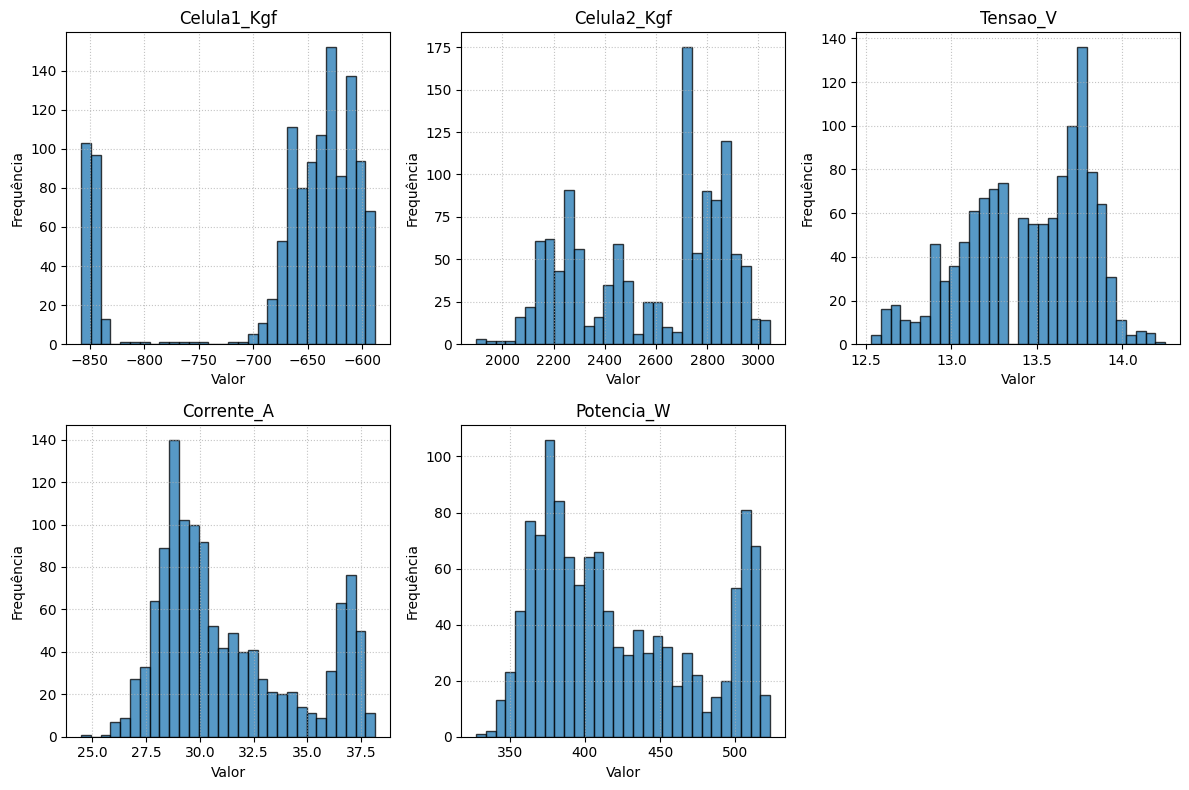

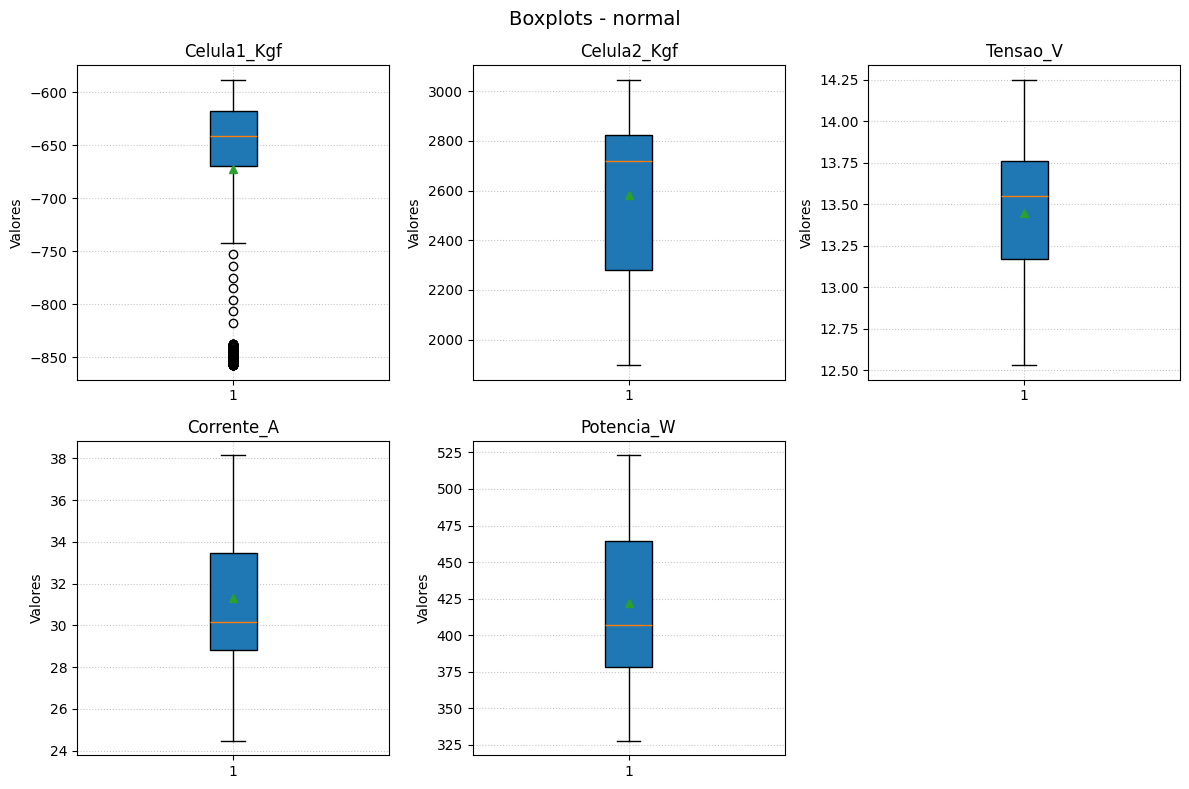



================== desbalanceada ==================

Transitorio 1, quantidade de dados =  509
Regime, quantidade de dados =  1190
Transitorio 2, quantidade de dados =  357
     Parametro        Media     Mediana       Moda     Maximo     Minimo  \
0  Celula1_Kgf  -873.745378  -924.00000  -580.0000  -526.0000 -1125.0000   
1  Celula2_Kgf  3022.717647  2742.00000  2589.0000  3957.0000  2362.0000   
2     Tensao_V    13.014353    12.96000    13.3900    13.9200    12.3100   
3   Corrente_A    38.148622    36.26500    45.0700    48.2200    28.2900   
4   Potencia_W   498.295829   467.87575   415.7244   671.2224   354.4737   

   Desvio padrao  Assimetria  Excesso de curtose  
0     172.628441    0.449034           -1.140558  
1     494.710529    0.598897           -1.488594  
2       0.361804    0.163761           -1.297751  
3       5.417096    0.432979           -1.472350  
4      84.169828    0.437243           -1.456159  


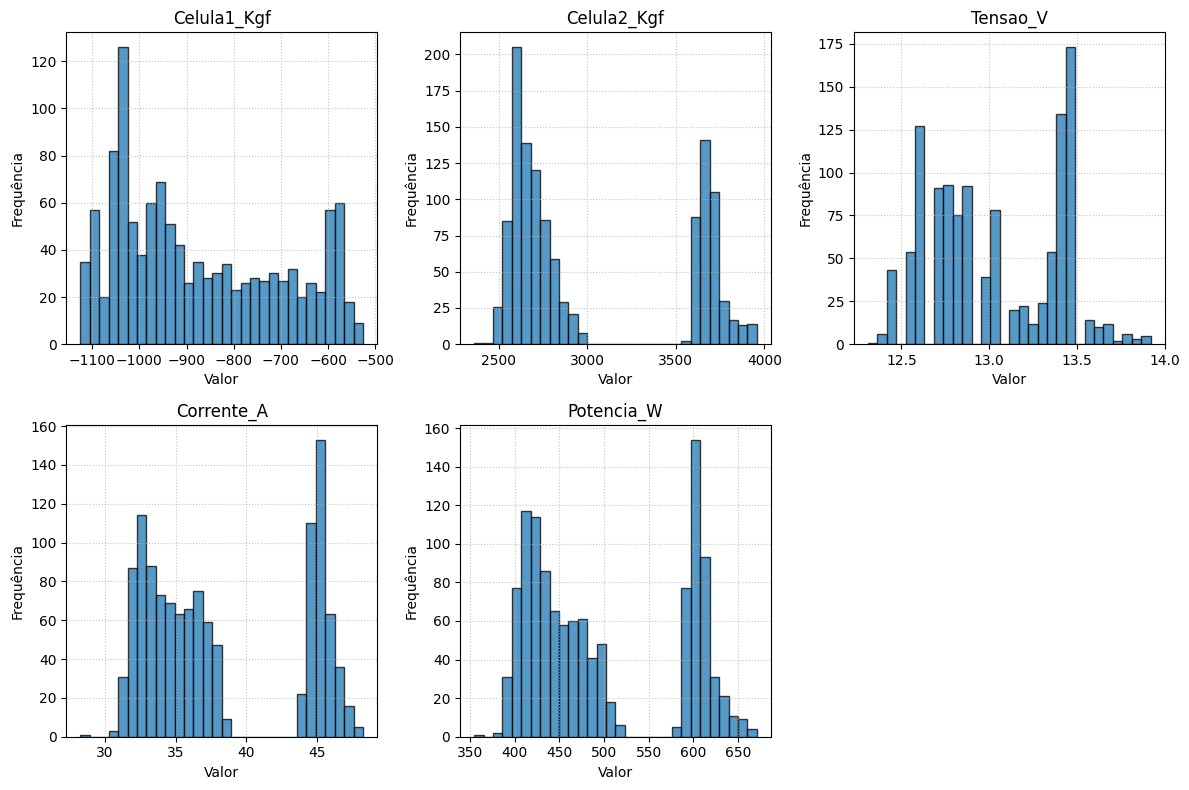

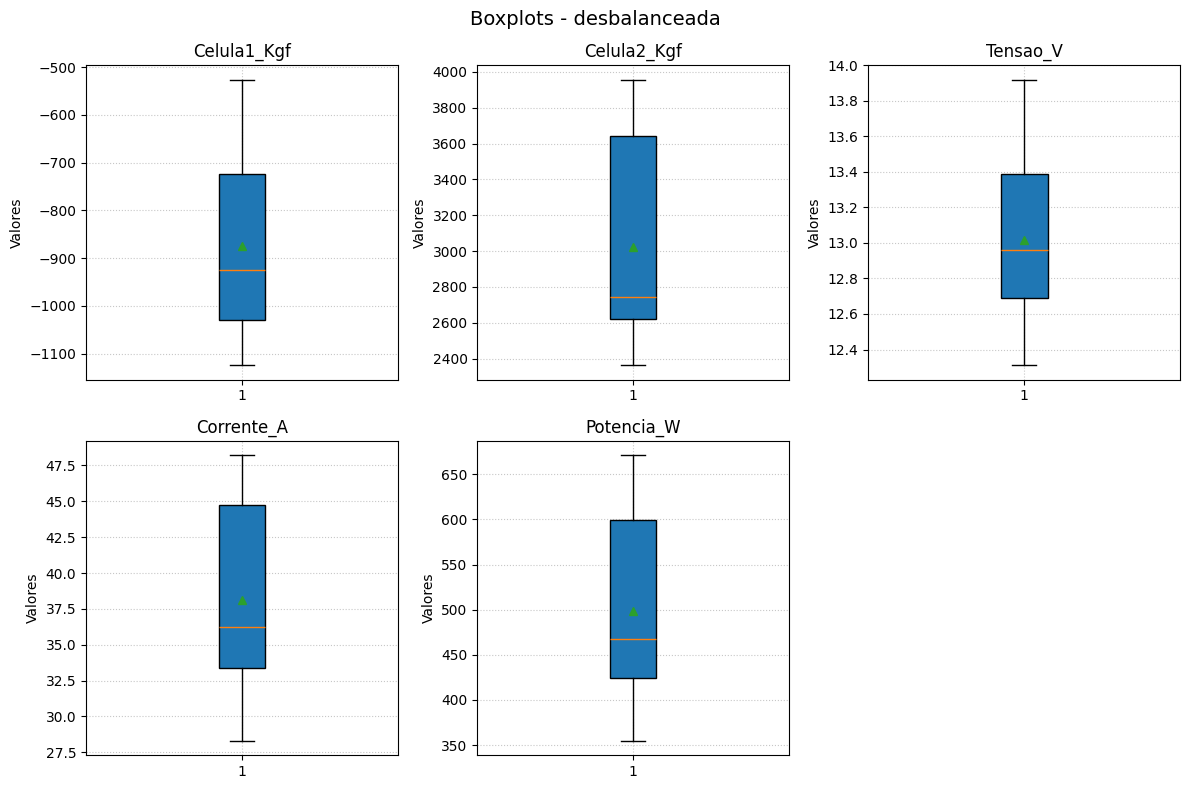



================== quebrada ==================

Transitorio 1, quantidade de dados =  575
Regime, quantidade de dados =  1919
Transitorio 2, quantidade de dados =  561
     Parametro        Media    Mediana       Moda     Maximo     Minimo  \
0  Celula1_Kgf  -560.890568  -555.0000  -555.0000  -420.0000 -1872.0000   
1  Celula2_Kgf  2448.909849  2489.0000  2218.0000  2799.0000  -793.0000   
2     Tensao_V    13.333121    13.3300    13.6000    14.2500    12.3100   
3   Corrente_A    33.439609    33.4200    30.7900    41.2200     5.3100   
4   Potencia_W   446.104344   437.4916   439.0875   584.9118    69.3486   

   Desvio padrao  Assimetria  Excesso de curtose  
0      86.704035   -9.079310          117.562332  
1     224.459022   -6.470499           75.819261  
2       0.341708   -0.183819           -0.980657  
3       2.507815   -0.383965            7.643722  
4      38.840483    0.280979            4.698181  


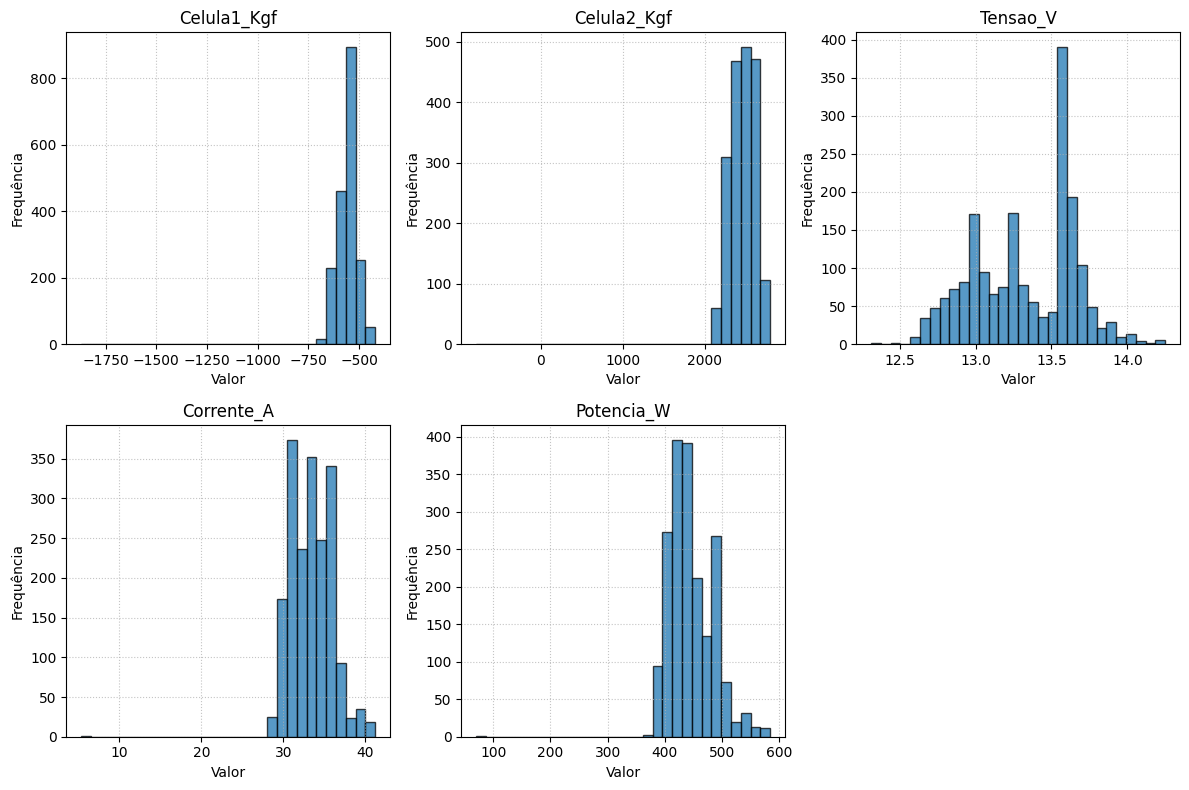

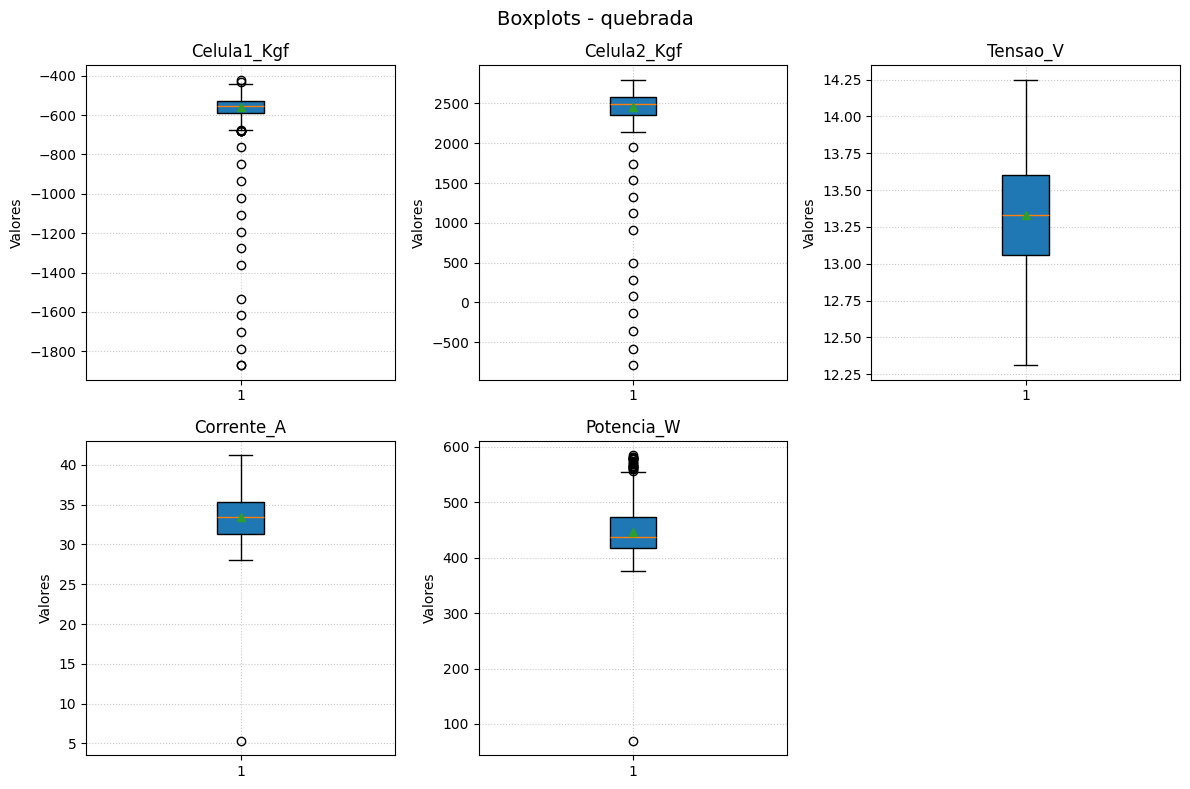



================== invertida ==================

Transitorio 1, quantidade de dados =  217
Regime, quantidade de dados =  816
Transitorio 2, quantidade de dados =  160
     Parametro        Media     Mediana      Moda     Maximo    Minimo  \
0  Celula1_Kgf   770.828431   768.00000   750.000   851.0000   716.000   
1  Celula2_Kgf -1695.457108 -1700.00000 -1677.000 -1473.0000 -1932.000   
2     Tensao_V    13.420613    13.55000    13.660    14.1900    12.690   
3   Corrente_A    38.844743    38.71000    39.090    43.1900    35.400   
4   Potencia_W   521.742076   520.74055   518.423   611.8728   449.226   

   Desvio padrao  Assimetria  Excesso de curtose  
0      26.365621    0.674885            0.496028  
1      90.685924    0.206762            0.291879  
2       0.313232   -0.467628           -0.456058  
3       1.527627    0.334532            0.212444  
4      31.726409    0.087115            0.093754  


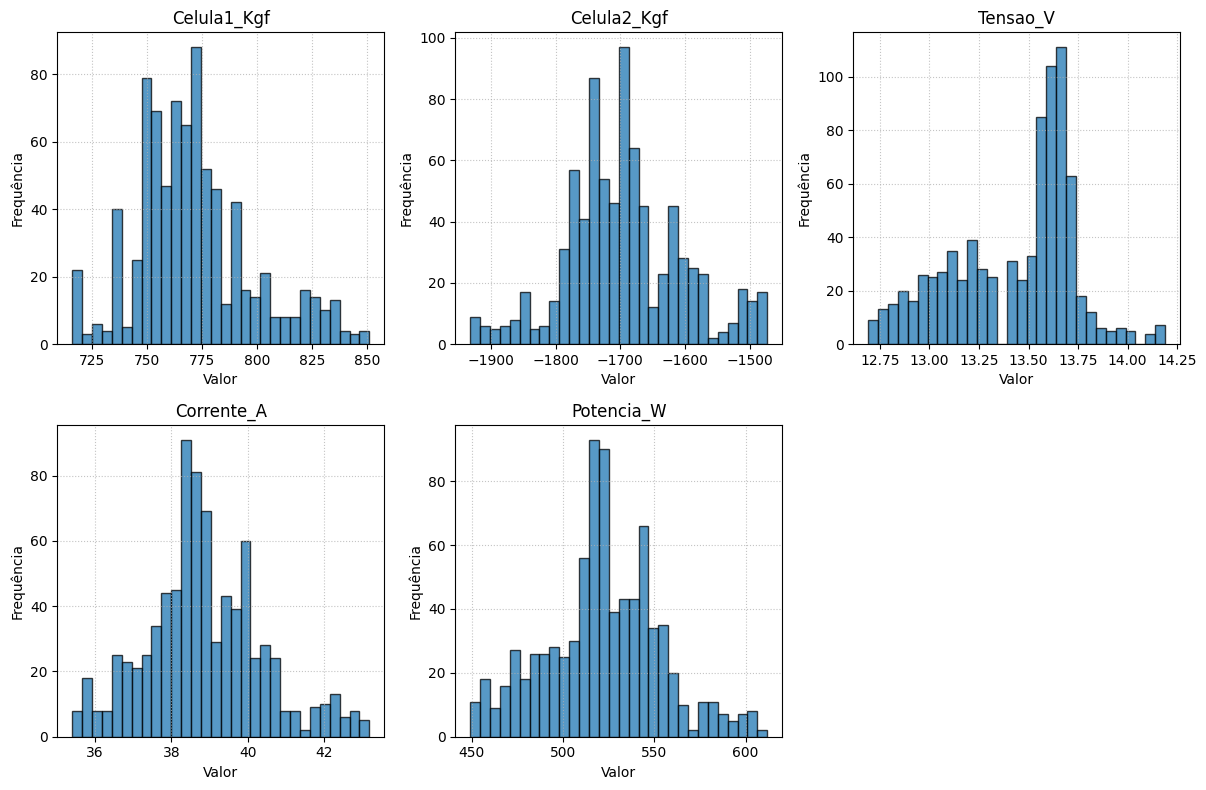

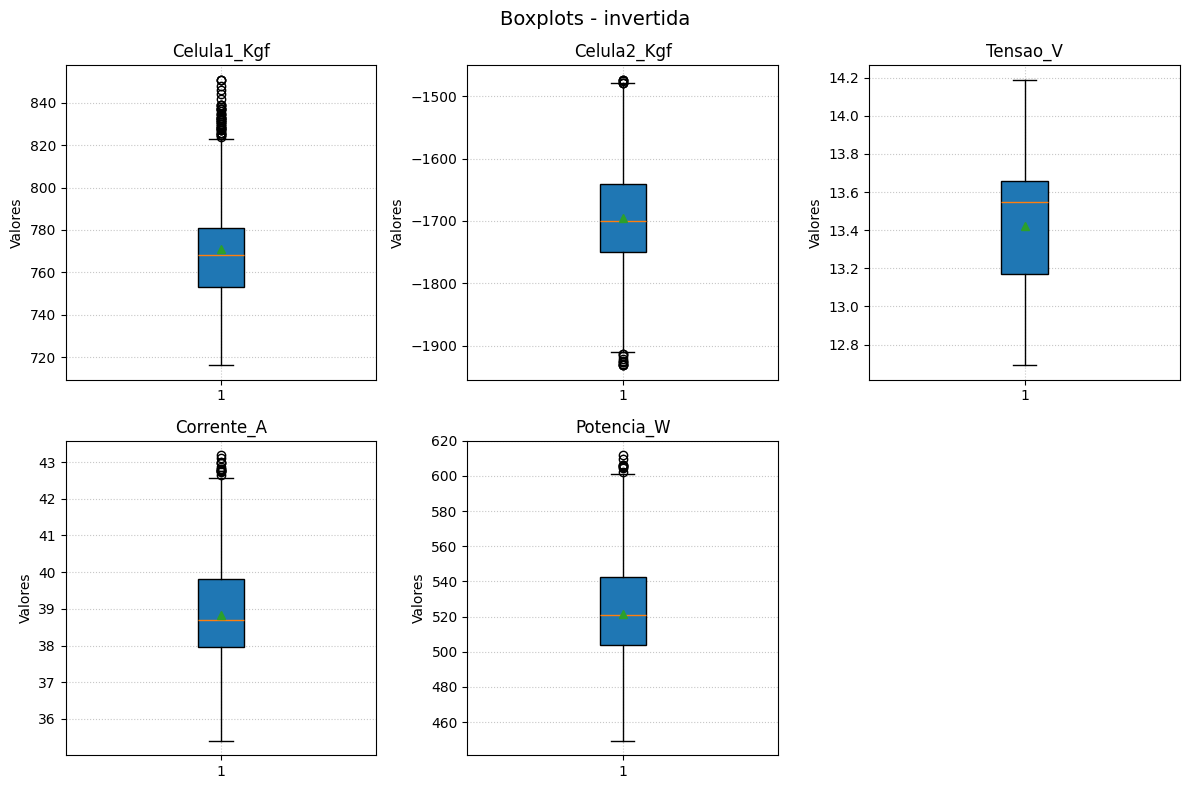

In [ ]:
for fold in folders:  # Para cada chave definida no dicionário "folders"...

    df0s = []   # Transitório inicial
    df1s = []   # Regime permanente
    df2s = []   # Transitório final

    tr1_tot_qty = 0
    regime_tot_qty = 0
    tr2_tot_qty = 0

    print("\n\n==================", fold, "==================\n")

    files_temp = [
        os.path.join(folders[fold], x)
        for x in os.listdir(folders[fold])
        if x.endswith(".xlsx")
    ]

    dfs = [pd.read_excel(f) for f in files_temp]

    for i, df_i in enumerate(dfs):

        # Remove colunas desnecessárias
        df_i = df_i.drop(columns="Celula3_Kgf")
        df_i = df_i.drop(columns="Tempo")
        df_i = df_i.drop(columns="RPM")

        # Segmentação
        df_0, df_1, df_2 = transitory_stacionary(df_i)

        # Soma quantidades
        tr1_tot_qty += len(df_0)
        regime_tot_qty += len(df_1)
        tr2_tot_qty += len(df_2)

        # Guarda regime permanente
        df1s.append(df_1)

    df1_tot = concatDataframes(df1s)


    op_tot = statisticsParams(
        fold,
        df1_tot,
        tr1_qty=tr1_tot_qty,
        regime_qty=regime_tot_qty,
        tr2_qty=tr2_tot_qty
    )

    stats_dataFrame(op_tot)

    header = df1_tot.columns.to_list()

    subplot_histogram(
        df1_tot,
        header,
        title=f"Histogramas - {fold}"
    )


    subplot_boxplot(df1_tot, header, title=f"Boxplots - {fold}")

   

### <span style="color:green;">Análise dos resultados dispostos </span>

A operação de hélice desbalanceada: 
- Retornou um valor maior de tração (Celula1_Kgf), em média, do que as outras operações, visto que, de acordo com a montagem dos componentes na bancada, sinal negativo indica tração para a célula de carga 1. Mesmo estando desbalanceada em massa, a hélice selecionada para realizar esse ensaio pode ter apresentado melhores características aerodinâmicas do que as outras, apesar de serem do mesmo modelo. 
- Nota-se uma maior dispersão dos valores conforme indicado pelo desvio padrão, o que é esperado, devido à assimetria de inércia no plano perpendicular ao diâmetro da hélice. 
- O valor negativo de "excesso de curtose" apresenta a tendência a uma curva platicúrtica para todos os parâmetros, indicando a ausência de valores extremos e caudas pesadas. Utilizando essa informação em conjunto com o valor de dispersão, implica em um comportamento muito variável mas sem picos isolados ou peso em uma das caudas.
- Ademais, para esse mesmo caso, é possível observar uma média de carga de torque (Celula2_Kgf) mais elevada quando comparado com as outras operações, o que é esperado pelo mesmo motivo do caso da tração, visto que a assimetria de inércia influencia no resultado das duas cargas analisadas. Durante o movimento rotacional da hélice, o desbalanceamento pode contribuir para a alternância entre eventos de alta carga aerodinâmica e baixa carga aerodinâmica, o que resulta em uma maior dispersão dos valores de torque. 

A operação normal: 
- Apresentou maior valor médio de tração, com exceção do caso de hélice desbalanceada, o que era esperado, visto que a operação com hélice quebrada deve apresentar queda de eficiência (devido à perda parcial de uma das pás) e a operação de rotação invertida deve indicar inversão do sinal, como é possível ver na disposição dos valores acima. 
- Em relação à corrente e potência, nota-se que os menores valores médios foram da operação normal, visto que as falhas podem gerar sobrecarga no sistema, como perda aerodinâmica e picos e alternâncias de carga, necessitando de uma maior entrega de potência e, consequentemente, corrente.
- O excesso de curtose observado foi baixo ou menor que zero, demonstrando que não houve a presença de picos e/ou vales extremos nesse tipo de operação, visto que não eram esperadas falhas.

Já a operação de hélice quebrada:
- Apesar de não conter grandes desvios quando comparado aos outros tipos de operação, apresentou queda brusca de tração devido à perda parcial de uma das pás, corroborando em uma alta perda aerodinâmica. 
- Por ser uma hélice do tipo tripá, a perda parcial de uma das pás pode ter apresentado menor influência na distribuição de inércia do que o caso da hélice desbalanceada, visto que, para o segundo caso, o desbalanceamento foi realizado pelo acúmulo de massa na extremidade de uma das pás, gerando uma grande distância do centro de massa inicial. Essa possível menor assimetria contribui para o baixo desvio padrão.

Por fim, a operação invertida:
- Gerou compressão na célula de carga, dado a inversão de sinal comparado aos casos anteriores. 
- Nota-se que os valores de corrente foram distribuidos de forma semelhante ao caso de operação normal, porém, em uma região com valores superiores, gerando maiores valores de potência, além de um excesso de curtose um pouco superior. Por estar sendo submetida à um movimento contrário ao que deveria ser realizado, o perfil aerodinâmico observado apresenta baixa eficiência, implicando em um maior arrasto nesse tipo de operação, o que gera uma sobrecarga no sistema, levando a maiores valores de potência e corrente. 

### <span style="color:green;">Repetibilidade das amostras</span>
As análises realizadas anteriormente foram feitas a partir da concatenação de todas as amostras obtidas para cada tipo de operação. Visando observar a repetibilidade entre amostras, a função abaixo foi desenvolvida.

A função "individualMetrics" apresenta como argumento uma lista, que deve conter todos os DataFrames de uma operação respectiva. Para cada parâmetro, a função obtém a média das médias e o coeficiente de variação das médias. Dessa forma, apresenta-se a variabilidade entre as métricas de uma mesma operação.

In [ ]:
def individualMetrics(df_list):

    header = df_list[0].columns.to_list()   # Adquire o cabeçalho dos dataframes
    mean_of_means = []  # Inicia a lista "mean_of_means" (média das médias) como vazia
    coefv_of_means = [] # Inicia a lista "coefv_of_means" (coeficiente de variação das médias) como vazia 
    i = 0
    for h in header:
        mean_list = []  # Lista de média
        for df in df_list:
            mean_list.append(df[h].mean())  # Para cada dataframe, calcula a média do parâmetro "h" e armazena na lista "mean_list"
            
        mean_of_means.append(st.mean(mean_list))    # Ao finalizar para o parâmetro atual, armazena a lista "mean_list" em "mean of means"
        coefv_of_means.append(100*st.stdev(mean_list)/st.mean(mean_list))   # Faz o mesmo para a lista de coeficientes de variação

    # Cria um dataframe para facilitar a visualização das variáveis no terminal
    data_frame = pd.DataFrame({
        "Parameter": header,
        "Media": mean_of_means,
        "Coeficiente de Variação [%]": coefv_of_means
    })

    print(data_frame)            

De modo semelhante ao que foi realizado anteriormente, o algoritmo abaixo realiza a verificação de todas as operações por meio do uso da função definida acima.

In [ ]:
for fold in folders:
    df1s = []
   
    tr1_tot_qty = 0
    tr2_tot_qty = 0
    regime_tot_qty = 0

    print("")
    print("")
    print("==================", fold, "==================")
    print("")

    files_temp = [os.path.join(folders[fold], x) for x in os.listdir(folders[fold]) if x.endswith(".xlsx")]

    # Cria uma lista com todos os DataFrames contidos na pasta atual
    dfs = [pd.read_excel(f) for f in files_temp]

    # Acessa cada DataFrame da lista de DataFrames da pasta atual
    for i, df_i in enumerate(dfs):

        df_i = df_i.drop(columns="Celula3_Kgf")
        df_i = df_i.drop(columns="Tempo")
        df_i = df_i.drop(columns="RPM")
       
        df_0, df_1, df_2 = transitory_stacionary(df_i)
        df1s.append(df_1)

    print("Quantidade de aquisições realizadas:", len(df1s))
    individualMetrics(df1s)



================== normal ==================

Quantidade de aquisições realizadas: 3
     Parameter        Media  Coeficiente de Variação [%]
0  Celula1_Kgf  -640.714164                    -3.398545
1  Celula2_Kgf  2586.675625                    10.791265
2     Tensao_V    13.444487                     2.313888
3   Corrente_A    31.322877                    11.097289
4   Potencia_W   421.952348                    13.449396


================== desbalanceada ==================

Quantidade de aquisições realizadas: 3
     Parameter        Media  Coeficiente de Variação [%]
0  Celula1_Kgf  -873.582081                   -10.976757
1  Celula2_Kgf  3010.687832                    19.596090
2     Tensao_V    13.003633                     2.966203
3   Corrente_A    37.951517                    17.105850
4   Potencia_W   495.326127                    20.206225


================== quebrada ==================

Quantidade de aquisições realizadas: 5
     Parameter        Media  Coeficiente de Va

Nota-se que, em geral, o coeficiente de variação dos parâmetros para cada tipo de operação apresentou baixos valores. Os maiores valores observados foram referentes às operações normal e de hélice desbalanceada. O caso de hélice desbalanceada se torna mais preocupante, visto que o valor de potência apresentou coeficiente de variação de 20,2%, sendo relativamente bem acima da média observada nas outras operações.

Esse desvio pode indicar a necessidade de se obter uma maior quantidade de amostras de hélice desbalanceada para o Trabalho 2, referente à técnicas de Machine Learning, visando adquirir maior assertividade na estimativa de comportamento do sistema submetido à esse tipo de falha.

Um fator interessante a ser observado é referente ao coeficiente de variação da tensão, em que, para todas as operações, apresenta valores muito próximos. Isso porque o valor medido é o da tensão da bateria, que não apresenta grandes variações conforme o prosseguimento do ensaio.

## Conclusão 

Este trabalho apresentou uma aplicação prática de Machine Learning voltada à análise de falhas estruturais em motores brushless, utilizando dados reais obtidos em bancada experimental a partir do grupo motopropulsor utilizado pela equipe Trem Ki Voa Micro na competição de 2024 SAE Brasil AeroDesign. A motivação do estudo surgiu após uma falha no motor observada durante a competição de 2024, evidenciando a importância de métodos capazes de antecipar problemas operacionais.

A base de dados construída contemplou diferentes condições de operação e modos de falha, incluindo hélice normal, hélice quebrada, hélice desbalanceada, rotação inversa e variações de carga (+Xg), com múltiplos ensaios realizados para cada cenário. Durante a coleta, foram monitoradas cinco variáveis principais: tração, torque, corrente, potência e tensão, fornecendo informações relevantes sobre o comportamento do sistema.

A análise exploratória dos dados permitiu identificar padrões no regime permanente, além de diferenças claras entre condições normais e situações anormais. O tratamento dos sinais, incluindo etapas de filtragem, contribuiu para reduzir ruídos e tornar as informações mais adequadas para futuras etapas de modelagem.

Considerando o objetivo do projeto, a abordagem de aprendizado de máquina mais adequada é a classificação, pois busca-se determinar se o sistema está operando em condição normal ou sob algum tipo de falha. Assim, modelos supervisionados podem ser treinados com exemplos rotulados de cada condição, permitindo o reconhecimento automático de novos estados operacionais. Além disso, a base também apresenta potencial para aplicações futuras em regressão, estimando variáveis contínuas, e em previsão temporal, analisando tendências ao longo do tempo.

Entre os principais desafios encontrados, destacam-se a necessidade de pré-processamento dos dados, a variabilidade natural dos ensaios experimentais, a limitação de amostras em alguns modos de falha e a escolha adequada das variáveis mais representativas para treinamento dos modelos.

Por fim, conceitos como sobreajuste, subajuste e o compromisso entre viés e variância mostram-se fundamentais nesse contexto. Um modelo excessivamente complexo pode memorizar ruídos específicos dos ensaios, enquanto modelos muito simples podem não capturar os padrões reais do sistema. Dessa forma, técnicas adequadas de validação e seleção de modelos serão essenciais para garantir robustez e capacidade de generalização.

Conclui-se, portanto, que os resultados obtidos demonstram o potencial da integração entre engenharia experimental e o machine learning no desenvolvimento de soluções de monitoramento de condição e manutenção preditiva, contribuindo para sistemas mais seguros, confiáveis e eficientes.

